# **Sales Prediction Model**

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import (
    SelectKBest,
    f_regression
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_csv("Advertising.csv")
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


### **Data Cleaning**

In [9]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print(df.shape)

df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Values")
print(df.duplicated().sum())

(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB

Missing Values
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate Values
0


In [10]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [11]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


### **Correlation Heatmap**

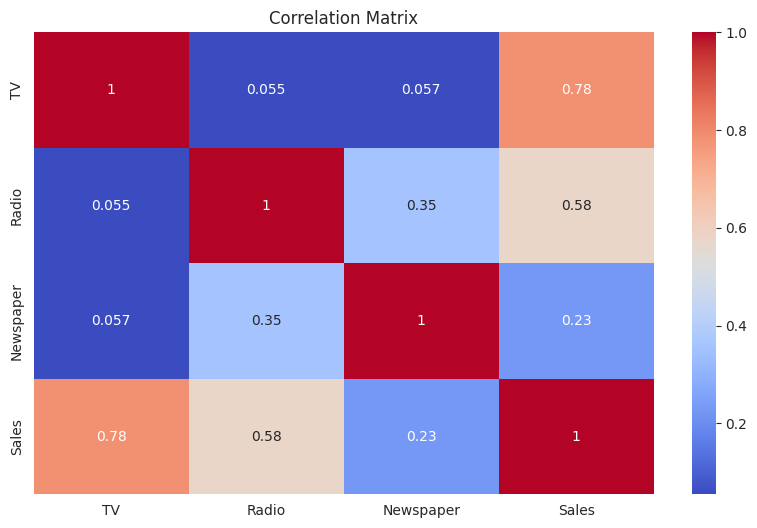

In [12]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

## **Distribution Analysis**

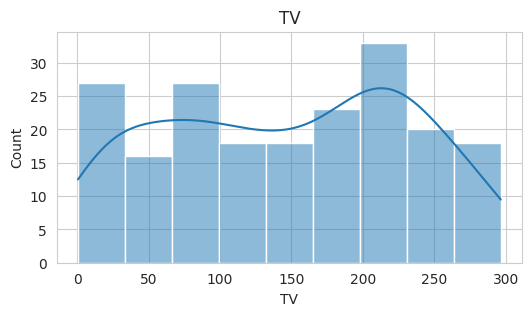

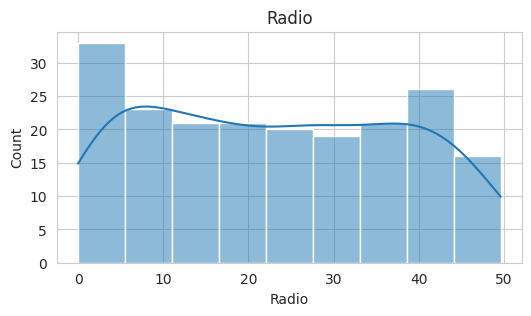

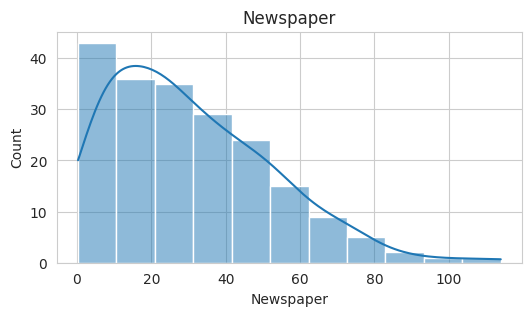

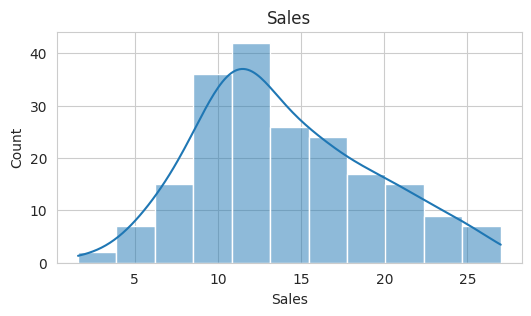

In [13]:
for col in df.columns:

    plt.figure(figsize=(6,3))

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

### **Box Plot**

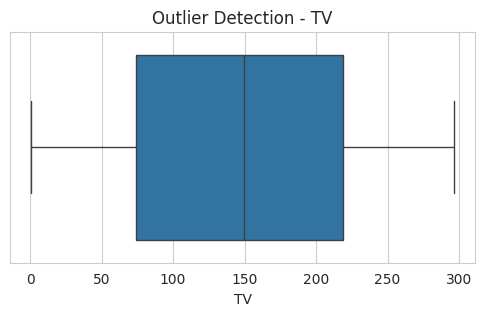

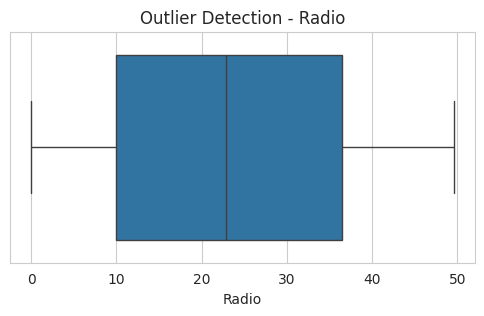

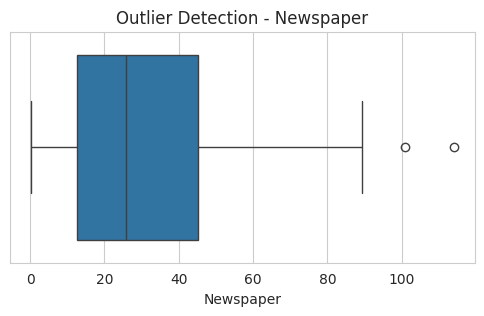

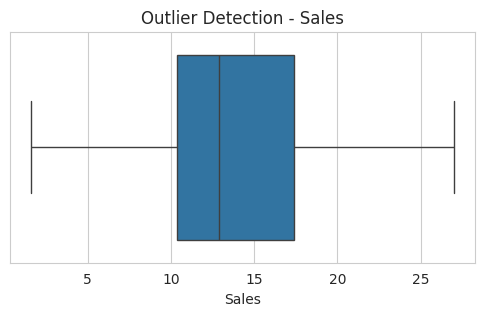

In [14]:
for col in df.columns:

    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Detection - {col}")

    plt.show()

### **Feature Engineering**

In [22]:
df["Total_Advertising"] = (
    df["TV"] +
    df["Radio"] +
    df["Newspaper"]
)

df["TV_Radio"] = (
    df["TV"] *
    df["Radio"]
)

df["TV_Newspaper"] = (
    df["TV"] *
    df["Newspaper"]
)

df["Radio_Newspaper"] = (
    df["Radio"] *
    df["Newspaper"]
)

df["ROI"] = (
    df["Sales"] /
    (df["Total_Advertising"] + 1)
)

df["Ad_Efficiency"] = (
    df["Sales"] /
    (df["TV"] + 1)
)

df

,TV,Radio,Newspaper,Sales,Total_Advertising,TV_Radio,TV_Newspaper,Radio_Newspaper,ROI,Ad_Efficiency
0,230.1,37.8,69.2,22.1,337.1,8697.78,15922.92,2615.76,0.065365,0.095630
1,44.5,39.3,45.1,10.4,128.9,1748.85,2006.95,1772.43,0.080062,0.228571
2,17.2,45.9,69.3,9.3,132.4,789.48,1191.96,3180.87,0.069715,0.510989
3,151.5,41.3,58.5,18.5,251.3,6256.95,8862.75,2416.05,0.073325,0.121311
4,180.8,10.8,58.4,12.9,250.0,1952.64,10558.72,630.72,0.051394,0.070957
...,...,...,...,...,...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,55.7,141.34,527.16,51.06,0.134039,0.193878
196,94.2,4.9,8.1,9.7,107.2,461.58,763.02,39.69,0.089649,0.101891
197,177.0,9.3,6.4,12.8,192.7,1646.10,1132.80,59.52,0.066082,0.071910
198,283.6,42.0,66.2,25.5,391.8,11911.20,18774.32,2780.40,0.064919,0.089599


### **Marketing Segmentation**

In [23]:
df["Marketing_Segment"] = pd.qcut(
    df["Total_Advertising"],
    q=3,
    labels=[
        "Low Budget",
        "Medium Budget",
        "High Budget"
    ]
)

df

,TV,Radio,Newspaper,Sales,Total_Advertising,TV_Radio,TV_Newspaper,Radio_Newspaper,ROI,Ad_Efficiency,Marketing_Segment
0,230.1,37.8,69.2,22.1,337.1,8697.78,15922.92,2615.76,0.065365,0.095630,High Budget
1,44.5,39.3,45.1,10.4,128.9,1748.85,2006.95,1772.43,0.080062,0.228571,Low Budget
2,17.2,45.9,69.3,9.3,132.4,789.48,1191.96,3180.87,0.069715,0.510989,Low Budget
3,151.5,41.3,58.5,18.5,251.3,6256.95,8862.75,2416.05,0.073325,0.121311,High Budget
4,180.8,10.8,58.4,12.9,250.0,1952.64,10558.72,630.72,0.051394,0.070957,High Budget
...,...,...,...,...,...,...,...,...,...,...,...
195,38.2,3.7,13.8,7.6,55.7,141.34,527.16,51.06,0.134039,0.193878,Low Budget
196,94.2,4.9,8.1,9.7,107.2,461.58,763.02,39.69,0.089649,0.101891,Low Budget
197,177.0,9.3,6.4,12.8,192.7,1646.10,1132.80,59.52,0.066082,0.071910,Medium Budget
198,283.6,42.0,66.2,25.5,391.8,11911.20,18774.32,2780.40,0.064919,0.089599,High Budget


### **Segment Analysis**

Marketing_Segment
Low Budget        8.946269
Medium Budget    14.160606
High Budget      18.962687
Name: Sales, dtype: float64


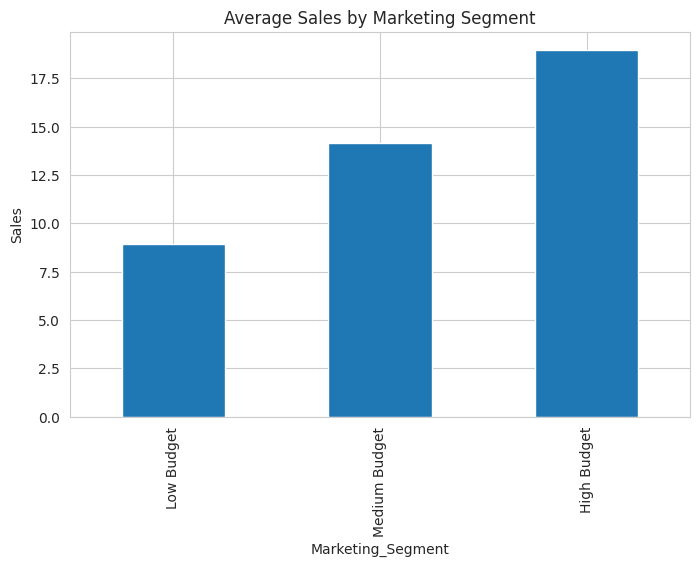

In [24]:
segment_analysis = df.groupby(
    "Marketing_Segment"
)["Sales"].mean()

print(segment_analysis)

segment_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Average Sales by Marketing Segment"
)

plt.ylabel("Sales")

plt.show()

### **Feature Selection**

In [25]:
temp_df = df.copy()

temp_df = pd.get_dummies(
    temp_df,
    drop_first=True
)

X = temp_df.drop("Sales", axis=1)

y = temp_df["Sales"]

selector = SelectKBest(
    score_func=f_regression,
    k='all'
)

selector.fit(X, y)

scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores.sort_values(
    by="Score",
    ascending=False,
    inplace=True
)

print(scores)

                            Feature        Score
4                          TV_Radio  2597.227925
3                 Total_Advertising   603.374934
0                                TV   312.144994
10    Marketing_Segment_High Budget   164.577144
5                      TV_Newspaper   122.691160
1                             Radio    98.421588
8                     Ad_Efficiency    85.086531
6                   Radio_Newspaper    41.409935
7                               ROI    25.572592
2                         Newspaper    10.887299
9   Marketing_Segment_Medium Budget     0.068697


### **Train The data**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42
)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### **Linear Regression**

In [30]:
lr = LinearRegression()

lr.fit(X_train_scaled,y_train)

lr_pred = lr.predict(X_test_scaled)

### **Gradient Boosting**

In [31]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(
    X_train,
    y_train
)

gb_pred = gb.predict(
    X_test
)

### **Hyper Paramater Tuning**

In [32]:
params = {
    'n_estimators':[100,200,300],

    'max_depth':[5,10,15],

    'min_samples_split':[2,5]

}

grid = GridSearchCV(

    RandomForestRegressor(
        random_state=42
    ),

    params,

    cv=5,

    scoring='r2',

    n_jobs=-1

)

grid.fit(
    X_train,
    y_train
)

best_model = grid.best_estimator_

print("Best Parameters")

print(grid.best_params_)

Best Parameters
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


### **Random Forest Prediction**

In [33]:
rf_pred = best_model.predict(
    X_test
)

### **Evaluation Model**

In [37]:
def evaluate_model(
    y_true,
    y_pred,
    name
):
    print("\n",name)
    print("Mean Absolute Error:",mean_absolute_error(y_true,y_pred))
    print("RMSE:",np.sqrt(mean_squared_error(y_true,y_pred)))
    print("R2:",r2_score(y_true,y_pred))

evaluate_model(
    y_test,
    lr_pred,
    "Linear Regression")

evaluate_model(
    y_test,
    gb_pred,
    "Gradient Boosting")

evaluate_model(
    y_test,
    rf_pred,
    "Optimized Random Forest")


 Linear Regression
Mean Absolute Error: 0.4238212066700494
RMSE: 0.5949940707549592
R2: 0.9887839785596798

 Gradient Boosting
Mean Absolute Error: 0.4475261449287011
RMSE: 0.60509915338176
R2: 0.9883997687866793

 Optimized Random Forest
Mean Absolute Error: 0.4688921794871779
RMSE: 0.5922586112035991
R2: 0.988886871839655


In [38]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":
    best_model.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

print(importance)

                            Feature  Importance
4                          TV_Radio    0.862334
3                 Total_Advertising    0.069181
0                                TV    0.055023
5                      TV_Newspaper    0.004214
8                     Ad_Efficiency    0.004044
1                             Radio    0.001777
7                               ROI    0.001381
2                         Newspaper    0.001267
6                   Radio_Newspaper    0.000705
9   Marketing_Segment_Medium Budget    0.000039
10    Marketing_Segment_High Budget    0.000036


### **Feature Iportance Plot**

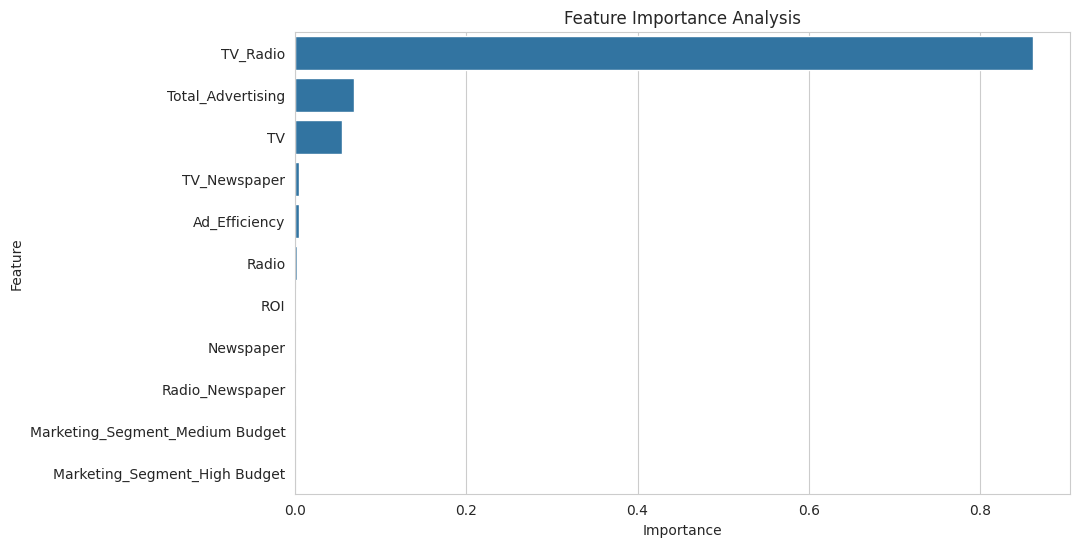

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title(
    "Feature Importance Analysis"
)

plt.show()

In [41]:
def predict_sales(
    tv,
    radio,
    newspaper
):

    total = (
        tv +
        radio +
        newspaper
    )
    roi = 0
    efficiency = 0
    sample = pd.DataFrame({

        'TV':[tv],
        'Radio':[radio],
        'Newspaper':[newspaper],
        'Total_Advertising':[total],
        'TV_Radio':[tv*radio],
        'TV_Newspaper':[tv*newspaper],
        'Radio_Newspaper':[radio*newspaper],
        'ROI':[roi],
        'Ad_Efficiency':[efficiency],
        'Marketing_Segment_Medium Budget':[1],
        'Marketing_Segment_High Budget':[0]

    })

    prediction = best_model.predict(
        sample
    )

    return prediction[0]

### Future Sales Forecast

In [42]:
future_sales = predict_sales(
    tv=250,
    radio=50,
    newspaper=40
)

print(
    "Predicted Future Sales:",
    round(future_sales,2)
)

Predicted Future Sales: 25.76


In [44]:
print("What-If Marketing Analysis")

for budget in [100,150,200,250,300]:

    sales = predict_sales(
        budget,
        budget*0.30,
        budget*0.20
    )

    print(f"Budget {budget} => Predicted Sales {sales:.2f}")

What-If Marketing Analysis
Budget 100 => Predicted Sales 14.18
Budget 150 => Predicted Sales 19.08
Budget 200 => Predicted Sales 25.21
Budget 250 => Predicted Sales 25.96
Budget 300 => Predicted Sales 26.06


Marketing Recommendation Engine

In [45]:
top_feature = importance.iloc[0]["Feature"]

print("\nMost Effective Marketing Factor:")

print(top_feature)


Most Effective Marketing Factor:
TV_Radio


In [49]:
budget = 100000
tv_budget = budget*0.50
radio_budget = budget*0.30
news_budget = budget*0.20

print("Recommended Budget Allocation: ")

print(f"TV : ₹{tv_budget:,.0f}")
print(f"Radio : ₹{radio_budget:,.0f}")
print(f"Newspaper : ₹{news_budget:,.0f}")

Recommended Budget Allocation: 
TV : ₹50,000
Radio : ₹30,000
Newspaper : ₹20,000


### **Final Business Insights**

In [52]:
print("\nBUSINESS INSIGHTS")

print("1. TV advertising contributes significantly to sales growth.")

print("2. Combined TV and Radio campaigns produce stronger results.")

print("3. High-budget campaigns achieve better average sales.")

print("4. Optimized Random Forest provides the highest predictive accuracy.")

print("5. Marketing budget allocation can be optimized using feature importance.")

print("6. What-if analysis helps businesses estimate future sales before investing.")


BUSINESS INSIGHTS
1. TV advertising contributes significantly to sales growth.
2. Combined TV and Radio campaigns produce stronger results.
3. High-budget campaigns achieve better average sales.
4. Optimized Random Forest provides the highest predictive accuracy.
5. Marketing budget allocation can be optimized using feature importance.
6. What-if analysis helps businesses estimate future sales before investing.
